# Milan Internet Traffic Analysis & Forecasting
This notebook demonstrates a complete end-to-end pipeline for loading, cleaning, exploring, and predicting cellular network traffic in Milan using Deep Learning models (LSTM, TCN, and Transformer).

---

## Step 1: Raw Data Extraction & In-Memory Optimization
*(Note: This cell is commented out as it only needs to be executed once when processing raw data from Google Drive. It is preserved here for reproducibility.)*

This step:
1. Mounts Google Drive.
2. Extracted the complete set of 62 `.txt` files containing spatial-temporal data.
3. Optimizes memory usage by downcasting data types (`int16` for Square IDs and `float32` for Traffic) and filtering out unnecessary columns (e.g., SMS/Call metrics) to load 89M+ rows within Google Colab RAM limits.

In [ ]:
# from google.colab import drive
# import os
# import zipfile
# import glob
# import pandas as pd
# import psutil

# # 1. Mount Google Drive
# drive.mount('/content/drive')

# def print_memory_usage(stage):
#     process = psutil.Process(os.getpid())
#     mem_gb = process.memory_info().rss / (1024 ** 3)
#     print(f"[{stage}] Current RAM Usage: {mem_gb:.2f} GB")

# print_memory_usage("Start")

# # 2. Setup Directories
# DRIVE_ZIP_DIR = "/content/drive/MyDrive/milan_data"
# LOCAL_EXTRACT_DIR = "/content/milan_data_unzipped"
# os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)

# # 3. Verify and Extract ZIP files
# zip_files = glob.glob(os.path.join(DRIVE_ZIP_DIR, "*.zip"))
# print(f"Found {len(zip_files)} ZIP files in Drive.")

# total_txt_files = 0
# for zf in zip_files:
#     with zipfile.ZipFile(zf, 'r') as zip_ref:
#         # Count only the .txt files inside the zip
#         txt_files_in_zip = [f for f in zip_ref.namelist() if f.endswith('.txt')]
#         total_txt_files += len(txt_files_in_zip)

#         print(f"Extracting {len(txt_files_in_zip)} files from {os.path.basename(zf)}...")
#         zip_ref.extractall(LOCAL_EXTRACT_DIR)

# print(f"\nTotal .txt files extracted: {total_txt_files}")
# if total_txt_files == 62:
#     print("Dataset is complete!")
# else:
#     print("Verification Warning: Expected 62 files. Dataset maybe incomplete.")

# print_memory_usage("Post-Extraction")

# # 4. Memory-Optimized Data Loading
# columns = ['Square_ID', 'Time_Interval', 'Country_Code', 'SMS_in', 'SMS_out', 'Call_in', 'Call_out', 'Internet_Traffic']
# cols_to_use = ['Square_ID', 'Time_Interval', 'Internet_Traffic']

# # Downcast to save RAM (Square_ID max is 10000, easily fits in int16)
# dtypes = {
#     'Square_ID': 'int16',
#     'Time_Interval': 'int64',
#     'Internet_Traffic': 'float32'
# }

# print("\nLoading and optimizing text files...")
# extracted_txt_files = glob.glob(os.path.join(LOCAL_EXTRACT_DIR, "*.txt"))

# data_frames = []
# for file in extracted_txt_files:
#     # Read chunk, discarding SMS/Call columns immediately
#     df_chunk = pd.read_csv(
#         file,
#         sep='\t',
#         header=None,
#         names=columns,
#         usecols=cols_to_use,
#         dtype=dtypes,
#         na_values=['']
#     )

#     # Aggregate internet traffic by Square ID and Time Interval to handle removed Country_Code separation
#     df_chunk = df_chunk.groupby(['Square_ID', 'Time_Interval'], as_index=False)['Internet_Traffic'].sum()
#     data_frames.append(df_chunk)

# # 5. Combine and Format
# master_df = pd.concat(data_frames, ignore_index=True)
# master_df['Time_Interval'] = pd.to_datetime(master_df['Time_Interval'], unit='ms')

# print_memory_usage("Post-Loading")
# print("\nFinal Dataset Info:")
# print(master_df.info())

## Step 2: Serializing the Cleaned Dataset
*(Note: This cell is commented out as it is only used to save the aggregated dataframe during your initial setup.)*

This step saves the massive `master_df` to Google Drive as an optimized **Apache Parquet** file. Parquet preserves data types, handles massive datasets efficiently, and allows you to load the complete processed dataset in seconds during future sessions.

In [ ]:
# import os

# # Define the save path in your Google Drive (saving it next to your ZIPs)
# DRIVE_DIR = "/content/drive/MyDrive/milan_data"
# PROCESSED_DATA_PATH = os.path.join(DRIVE_DIR, "milan_internet_optimized.parquet")

# print("Serializing optimized dataset to Google Drive...")
# # Write to Parquet (requires pyarrow or fastparquet, which Colab has pre-installed)
# master_df.to_parquet(PROCESSED_DATA_PATH, index=False)

# print(f"Data saved successfully to: {PROCESSED_DATA_PATH}")
# print("\nFor next session, you can skip the extraction and just run:")
# print(f"master_df = pd.read_parquet('{PROCESSED_DATA_PATH}')")

## Step 3: Fast Dataset Loading (Standard Session Entry Point)

Instead of unzipping 62 text files every time, this cell directly downloads the pre-processed Parquet dataset from a public Google Drive storage link (using `gdown`) and loads it instantly into memory. **This is the main entry point of the notebook for standard runs.**

In [ ]:
import gdown
import pandas as pd
import os


file_id = '1pNVID1tk1X67WSHwtm2IYSsc_EwygYhS'
url = f'https://drive.google.com/uc?id={file_id}'
output_file = 'milan_internet_optimized.parquet'


if not os.path.exists(output_file):
    print("Downloading dataset from Google Drive...")
    gdown.download(url, output_file, quiet=False)
else:
    print("File already exists locally.")

#Load the data
master_df = pd.read_parquet(output_file)
print("Data loaded successfully!")

Downloading...
From (original): https://drive.google.com/uc?id=1pNVID1tk1X67WSHwtm2IYSsc_EwygYhS
From (redirected): https://drive.google.com/uc?id=1pNVID1tk1X67WSHwtm2IYSsc_EwygYhS&confirm=t&uuid=a437cf70-5594-4a89-88f2-92447786c7a1
To: /content/milan_internet_optimized.parquet
100%|██████████| 409M/409M [00:03<00:00, 106MB/s]


Data loaded successfully!


## Step 4: Exploratory Data Analysis (EDA)

In this section, we analyze the distribution of traffic across all 10,000 grid squares to identify the most active regions in Milan:
1. Plot the overall traffic distribution on both Linear and Log scales to understand heavy-tailed behaviors.
2. Rank and select the top 3 high-traffic grid cells (Square IDs: `5161`, `5059`, and `5259`).
3. Visualize a 2-week time-series comparison across the top 3 areas along with two specific benchmark squares (`4159` and `4556`).

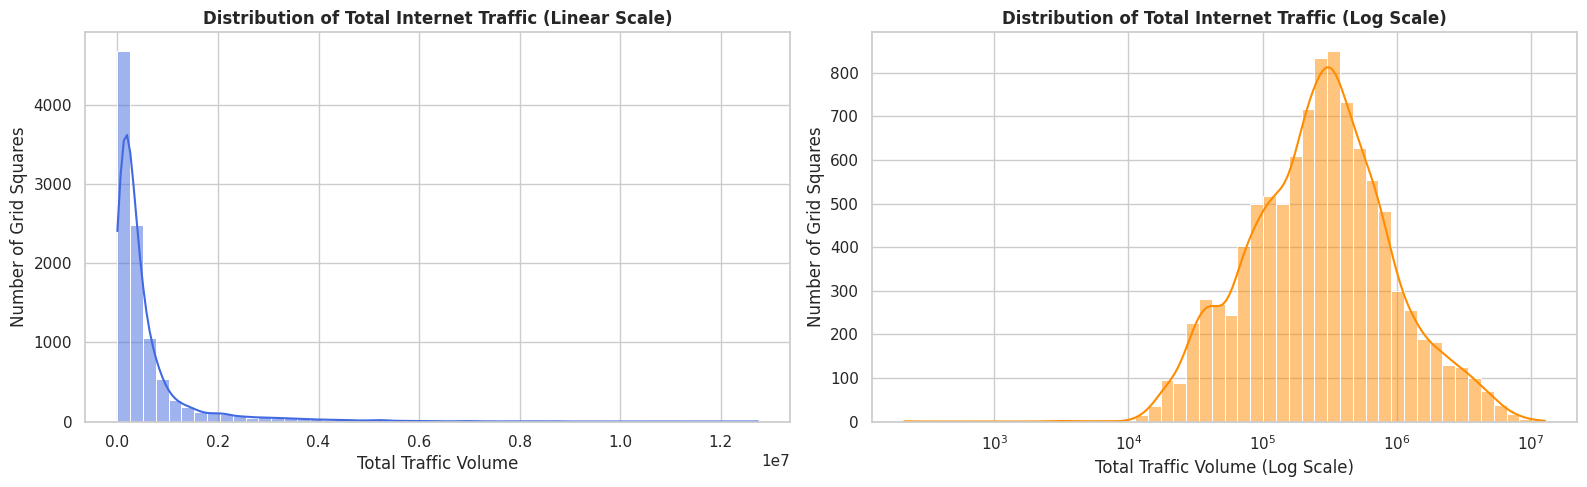

=== Traffic Distribution Statistics ===
count    1.000000e+04
mean     5.552894e+05
std      8.925966e+05
min      2.136265e+02
25%      1.181020e+05
50%      2.778711e+05
75%      5.778956e+05
90%      1.243960e+06
99%      4.698732e+06
max      1.274006e+07
Name: Total_Traffic, dtype: float64

=== Top 3 Geographical Areas by Total Traffic ===
Rank 1: Square ID 5161 with 12,740,060.00 total traffic
Rank 2: Square ID 5059 with 11,170,854.00 total traffic
Rank 3: Square ID 5259 with 10,485,780.00 total traffic

Target Squares for Analysis: [5161, 5059, 5259, 4159, 4556]


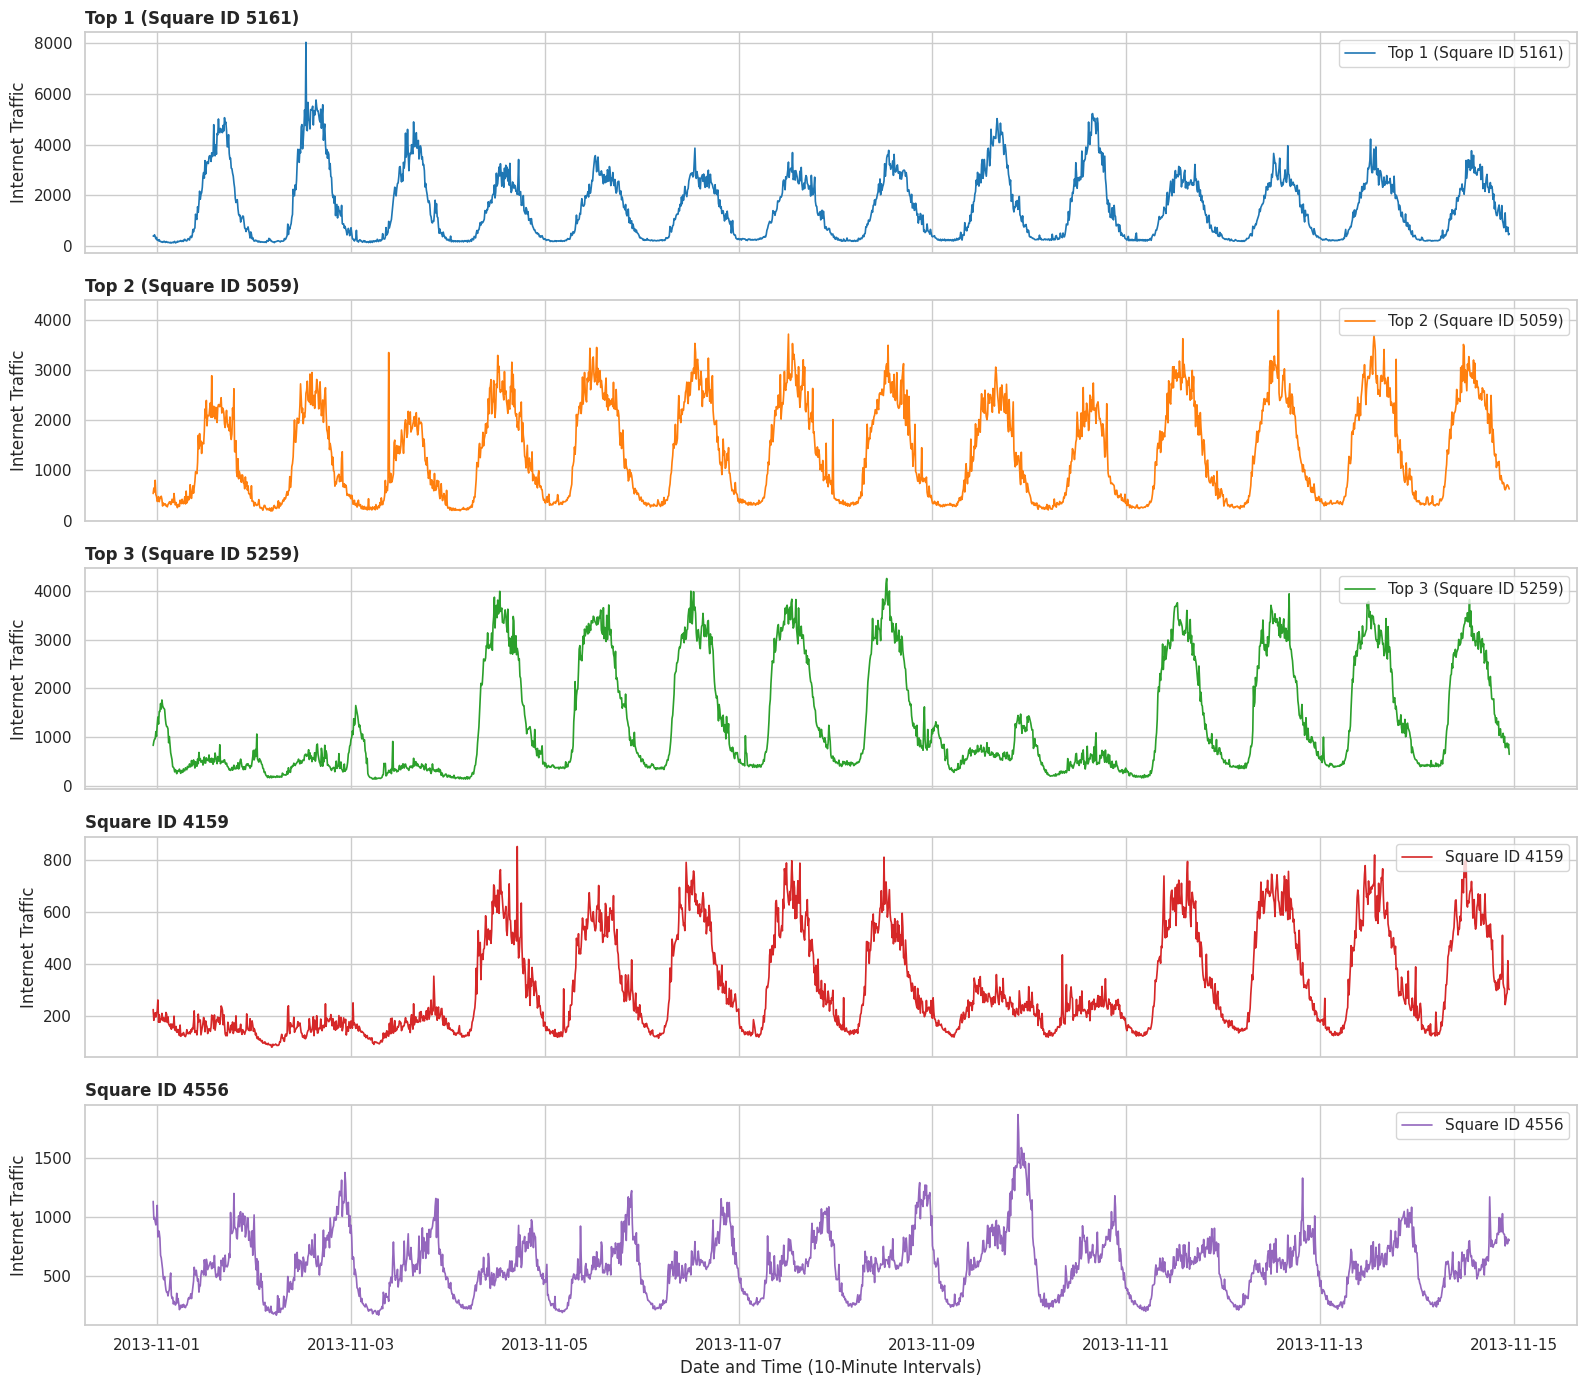

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})


# ==========================================================
# 1. Total Traffic Distribution Across All Geographical Areas
# ==========================================================
# Aggregate full two-month traffic by Square_ID
area_traffic = master_df.groupby('Square_ID', as_index=False)['Internet_Traffic'].sum()
area_traffic.rename(columns={'Internet_Traffic': 'Total_Traffic'}, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear scale histogram / KDE
sns.histplot(area_traffic['Total_Traffic'], bins=50, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Total Internet Traffic (Linear Scale)', fontweight='bold')
axes[0].set_xlabel('Total Traffic Volume')
axes[0].set_ylabel('Number of Grid Squares')

# Log scale histogram (telecom traffic typically exhibits heavy right-tail / Pareto behavior)
sns.histplot(area_traffic['Total_Traffic'], bins=50, kde=True, log_scale=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Total Internet Traffic (Log Scale)', fontweight='bold')
axes[1].set_xlabel('Total Traffic Volume (Log Scale)')
axes[1].set_ylabel('Number of Grid Squares')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_data/traffic_distribution.png', dpi=300)
plt.show()

# Print distribution summary metrics for your report discussion
print("=== Traffic Distribution Statistics ===")
print(area_traffic['Total_Traffic'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))

# ==========================================================
# 2. Identify Top 3 Geographical Areas
# ==========================================================
top_3_df = area_traffic.sort_values(by='Total_Traffic', ascending=False).head(3)
top_3_ids = top_3_df['Square_ID'].tolist()

print("\n=== Top 3 Geographical Areas by Total Traffic ===")
for rank, (idx, row) in enumerate(top_3_df.iterrows(), 1):
    print(f"Rank {rank}: Square ID {int(row['Square_ID'])} with {row['Total_Traffic']:,.2f} total traffic")

# Target squares required by the assignment
target_squares = top_3_ids + [4159, 4556]
print(f"\nTarget Squares for Analysis: {target_squares}")

# ==========================================================
# 3. Two-Week Time Series Visualization
# ==========================================================
# Filter for the first two weeks (14 days from earliest timestamp)
start_time = master_df['Time_Interval'].min()
end_time = start_time + pd.Timedelta(days=14)

two_week_df = master_df[
    (master_df['Square_ID'].isin(target_squares)) &
    (master_df['Time_Interval'] >= start_time) &
    (master_df['Time_Interval'] < end_time)
].copy()

# Sort chronologically
two_week_df.sort_values(by=['Square_ID', 'Time_Interval'], inplace=True)

# Plot separate panels for each area to clearly highlight differing dynamics
fig, axes = plt.subplots(len(target_squares), 1, figsize=(16, 14), sharex=True)

labels = {
    top_3_ids[0]: f"Top 1 (Square ID {top_3_ids[0]})",
    top_3_ids[1]: f"Top 2 (Square ID {top_3_ids[1]})",
    top_3_ids[2]: f"Top 3 (Square ID {top_3_ids[2]})",
    4159: "Square ID 4159",
    4556: "Square ID 4556"
}

for i, sq_id in enumerate(target_squares):
    subset = two_week_df[two_week_df['Square_ID'] == sq_id]
    axes[i].plot(subset['Time_Interval'], subset['Internet_Traffic'], label=labels[sq_id], color=sns.color_palette("tab10")[i], linewidth=1.2)
    axes[i].set_title(labels[sq_id], fontweight='bold', loc='left')
    axes[i].set_ylabel('Internet Traffic')
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel('Date and Time (10-Minute Intervals)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_data/two_week_timeseries.png', dpi=300)
plt.show()

## Step 5: Advanced Time Series Characterization

To prepare for forecasting, we perform a deep dive into the temporal dynamics of our highest-traffic area (Square ID `5161`):
1. **Autocorrelation (ACF) & Partial Autocorrelation (PACF)**: Investigates seasonal lag cycles (e.g., 24-hour patterns corresponding to 144 steps).
2. **STL Decomposition**: Decomposes the signal into trend, daily seasonal cycles, and residuals (anomalies/noise).
3. **Augmented Dickey-Fuller (ADF) Test**: Mathematically confirms whether our series is stationary and ready for training.

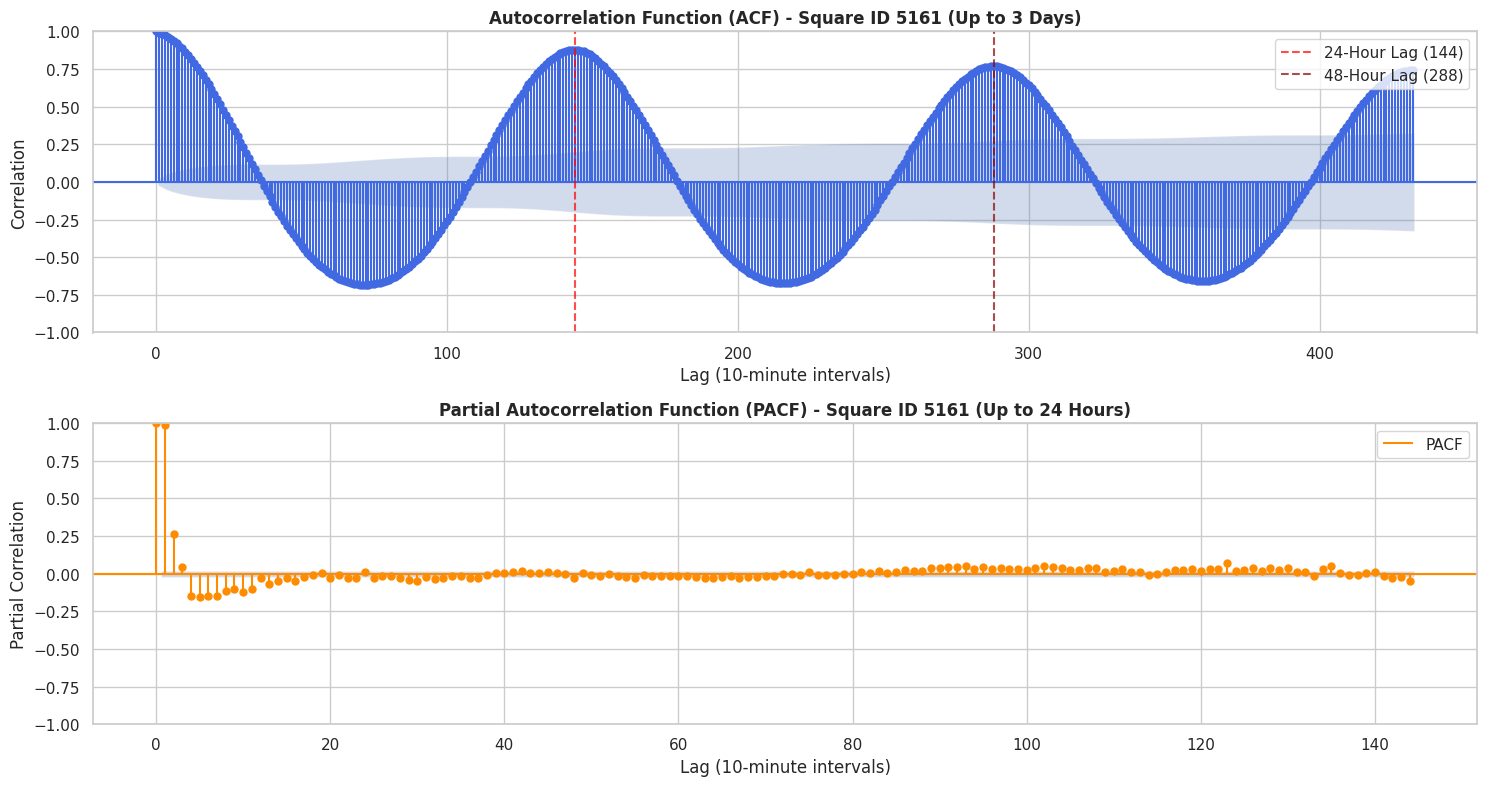

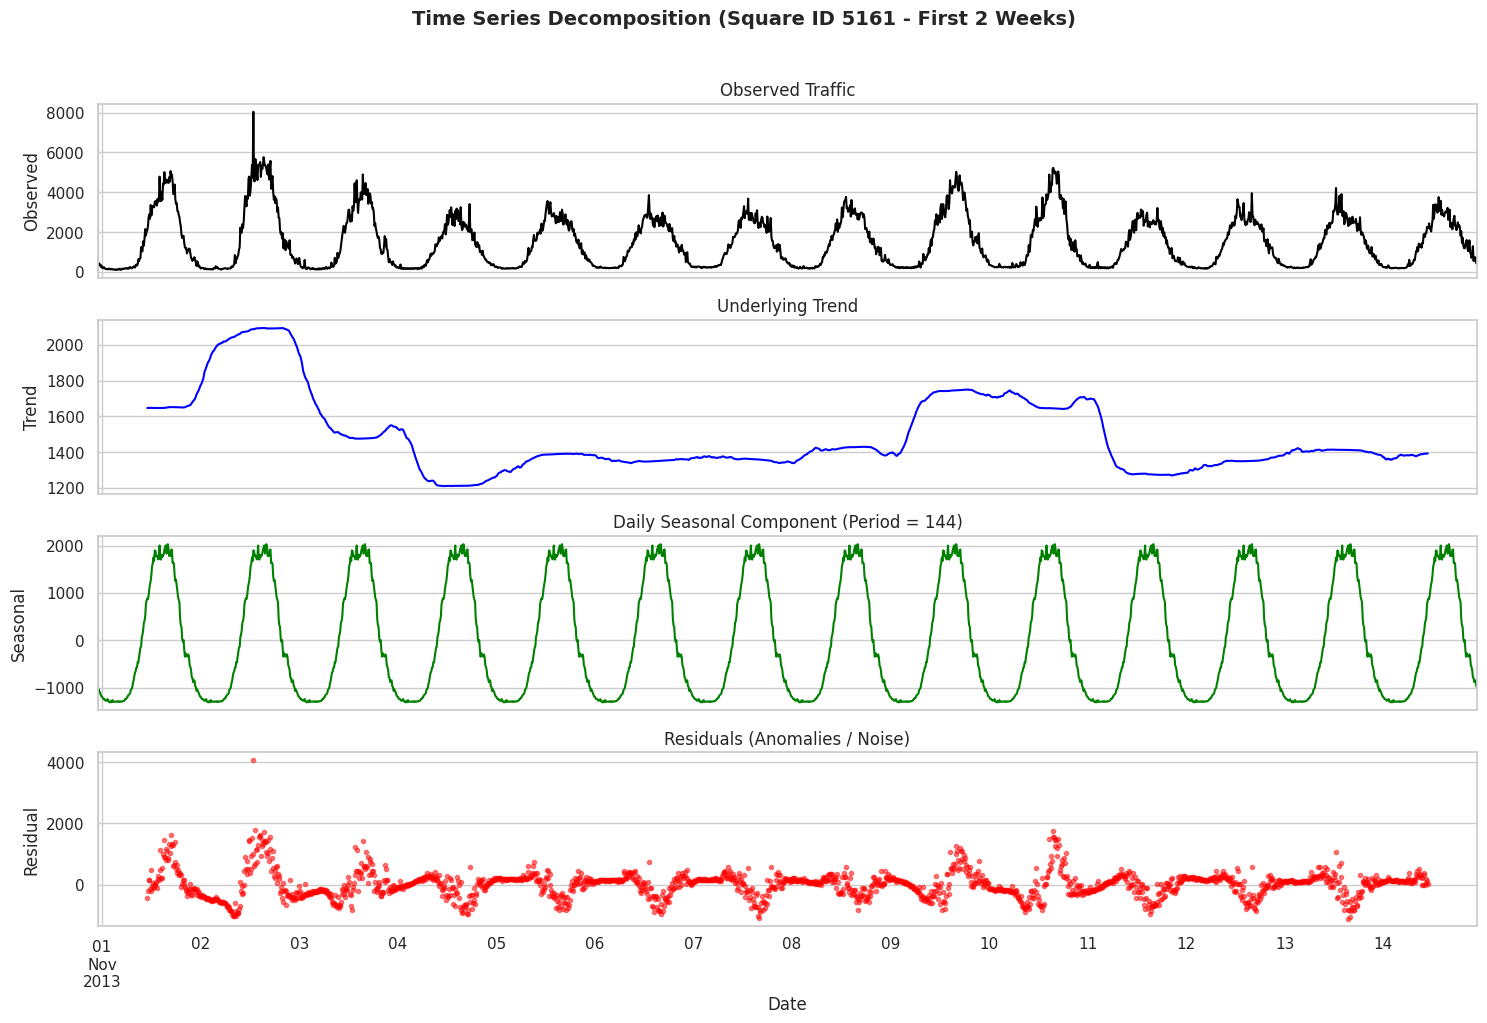

=== Augmented Dickey-Fuller (ADF) Stationarity Test ===
ADF Statistic: -19.0319
p-value: 0.0000e+00
Critical Values:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669
Conclusion: The series is stationary at the 5% significance level.


/tmp/ipykernel_1756/2978070884.py:70: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(ts_5161.dropna())


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# 1. Filter Top Area (Square ID 5161) for the full 2-month dataset
top1_df = master_df[master_df['Square_ID'] == 5161].copy()
top1_df.sort_values('Time_Interval', inplace=True)
top1_df.set_index('Time_Interval', inplace=True)

# Resample to strict 10-minute frequency and forward-fill any missing timestamps
ts_5161 = top1_df['Internet_Traffic'].asfreq('10min').ffill()

# ==========================================================
# Analysis 1: Autocorrelation (ACF) & Partial Autocorrelation (PACF)
# ==========================================================
# 10-min intervals: 1 day = 144 steps, 2 days = 288 steps
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# ACF up to 3 days (432 lags) to observe multi-day cyclical dependencies
plot_acf(ts_5161, lags=432, ax=axes[0], color='royalblue', vlines_kwargs={"colors": 'royalblue'})
axes[0].set_title('Autocorrelation Function (ACF) - Square ID 5161 (Up to 3 Days)', fontweight='bold')
axes[0].set_xlabel('Lag (10-minute intervals)')
axes[0].set_ylabel('Correlation')
axes[0].axvline(144, color='red', linestyle='--', alpha=0.7, label='24-Hour Lag (144)')
axes[0].axvline(288, color='darkred', linestyle='--', alpha=0.7, label='48-Hour Lag (288)')
axes[0].legend(loc='upper right')

# PACF up to 1 day (144 lags) to identify direct autoregressive order
plot_pacf(ts_5161, lags=144, ax=axes[1], method='yw', color='darkorange', vlines_kwargs={"colors": 'darkorange'})
axes[1].set_title('Partial Autocorrelation Function (PACF) - Square ID 5161 (Up to 24 Hours)', fontweight='bold')
axes[1].set_xlabel('Lag (10-minute intervals)')
axes[1].set_ylabel('Partial Correlation')
axes[1].legend(['PACF'], loc='upper right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_data/acf_pacf_analysis.png', dpi=300)
plt.show()

# ==========================================================
# Analysis 2: STL Decomposition & Augmented Dickey-Fuller (ADF) Test
# ==========================================================
# Decompose across a 2-week subset for visual clarity (period = 144 intervals / day)
decomp_slice = ts_5161.iloc[:144 * 14]
decomposition = seasonal_decompose(decomp_slice, model='additive', period=144)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color='black', title='Observed Traffic')
axes[0].set_ylabel('Observed')

decomposition.trend.plot(ax=axes[1], color='blue', title='Underlying Trend')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], color='green', title='Daily Seasonal Component (Period = 144)')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], color='red', style='.', alpha=0.5, title='Residuals (Anomalies / Noise)')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.suptitle('Time Series Decomposition (Square ID 5161 - First 2 Weeks)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_data/time_series_decomposition.png', dpi=300)
plt.show()

# Augmented Dickey-Fuller Test
adf_result = adfuller(ts_5161.dropna())
print("=== Augmented Dickey-Fuller (ADF) Stationarity Test ===")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4e}")
print("Critical Values:")
for key, val in adf_result[4].items():
    print(f"   {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print("Conclusion: The series is stationary at the 5% significance level.")
else:
    print("Conclusion: The series is non-stationary; differencing or de-trending is required.")

## Step 6: Dataset Engineering & Deep Learning PyTorch Dataloaders

We prepare our training and testing data for Deep Learning:
1. Separate the evaluation period (the final week of December 16 to 22) to prevent data leakage.
2. Normalize the data using `MinMaxScaler` onto a range of `[0, 1]` for more stable neural network training.
3. Create a custom PyTorch `Dataset` and sequential window `DataLoader` using a historical context window (`SEQ_LENGTH = 144`, representing 24 hours).

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Use the highest traffic area (Square ID 5161) for the training setup
top_area_df = master_df[master_df['Square_ID'] == 5161].copy()
top_area_df.sort_values('Time_Interval', inplace=True)

# Separate the evaluation week (December 16 to 22) from the training data
eval_start = pd.to_datetime('2013-12-16')
eval_end = pd.to_datetime('2013-12-23')

train_data = top_area_df[top_area_df['Time_Interval'] < eval_start]['Internet_Traffic'].values.reshape(-1, 1)
test_data = top_area_df[(top_area_df['Time_Interval'] >= eval_start) &
                        (top_area_df['Time_Interval'] < eval_end)]['Internet_Traffic'].values.reshape(-1, 1)

# Task 4.VI: Normalization Preprocessing
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

class TrafficDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, index):
        # Input history x_t: vector of traffic values up to t
        x = self.data[index:(index + self.seq_length)]
        # Target: future traffic at t+1
        y = self.data[index + self.seq_length]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Task 4.VI: Sequence Length Definition
SEQ_LENGTH = 144
BATCH_SIZE = 64

train_dataset = TrafficDataset(train_scaled, SEQ_LENGTH)
test_dataset = TrafficDataset(test_scaled, SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Step 7: Model Architectures - LSTM Forecaster

We define our first forecasting candidate: an **LSTM (Long Short-Term Memory)** network. This Recurrent Neural Network (RNN) structure excels at tracking long-term sequential dependencies over time.

In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super(LSTMForecaster, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Batch_first=True expects input shape (batch, seq_length, features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Pass through LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

## Step 8: Model Architectures - Temporal Convolutional Network (TCN)

We define our second candidate: a **Temporal Convolutional Network (TCN)**. This model uses 1D causal dilated convolutions, allowing it to process long sequential sequences in parallel with high computational efficiency.

In [ ]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TCNForecaster(nn.Module):
    def __init__(self, num_inputs=1, num_channels=[32, 64, 64], kernel_size=3):
        super(TCNForecaster, self).__init__()
        layers = []
        num_levels = len(num_channels)

        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            padding = (kernel_size - 1) * dilation_size

            # Causal dilated convolution
            layers += [
                nn.Conv1d(in_channels, out_channels, kernel_size,
                          stride=1, padding=padding, dilation=dilation_size),
                Chomp1d(padding), # Removes asymmetric padding to maintain causality
                nn.ReLU(),
                nn.Dropout(0.2)
            ]

        self.network = nn.Sequential(*layers)
        self.linear = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        # Conv1d expects shape (batch, channels, seq_length)
        x = x.transpose(1, 2)
        y1 = self.network(x)
        # Take the output of the final time step
        out = self.linear(y1[:, :, -1])
        return out

## Step 9: Model Architectures - Transformer Forecaster

We define our third candidate: a **Transformer Encoder** utilizing self-attention mechanisms and positional encoding. This allows the model to dynamically weigh and attend to historical steps regardless of temporal distance.

In [ ]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0) # Shape: (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :].to(x.device)

class TransformerForecaster(nn.Module):
    def __init__(self, feature_size=1, d_model=64, nhead=4, num_layers=2):
        super(TransformerForecaster, self).__init__()
        self.input_linear = nn.Linear(feature_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x):
        # x shape: (batch, seq_length, feature_size)
        x = self.input_linear(x)
        x = self.pos_encoder(x)

        # In a strict forecasting setup, a causal mask is ideal,
        # but extracting the final encoded token prevents looking ahead.
        encoded = self.transformer_encoder(x)
        out = self.decoder(encoded[:, -1, :])
        return out

## Step 10: Model Training & Evaluation Suite

This utility block contains the core training loop. It processes training batches on the GPU (if available) and evaluates the models on the test set using standard metrics:
* **MAE** (Mean Absolute Error)
* **RMSE** (Root Mean Squared Error)
* **MAPE** (Mean Absolute Percentage Error)
* **Training/Inference Execution Speeds**

In [ ]:
import time
import torch
import torch.nn as nn
import numpy as np

# Define the hardware device (Colab's free GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Helper function to calculate evaluation metrics
def calculate_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    # Add a small epsilon to avoid division by zero in MAPE
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

def train_and_evaluate(model, train_loader, test_loader, scaler, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []

    # Task 4.IV: Track exact training time
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            predictions = model(x_batch)

            # Ensure dimensions match (batch_size, 1)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {train_losses[-1]:.6f}")

    training_time = time.time() - start_time

    # Task 4.III: Evaluation Phase
    model.eval()
    all_predictions = []
    all_targets = []

    # Track exact inference/execution time
    infer_start_time = time.time()

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            all_predictions.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.numpy())

    inference_time = time.time() - infer_start_time

    # Inverse transform to calculate metrics in actual Internet Traffic units, not [0,1] scaled units
    y_true_unscaled = scaler.inverse_transform(np.array(all_targets).reshape(-1, 1))
    y_pred_unscaled = scaler.inverse_transform(np.array(all_predictions).reshape(-1, 1))

    mae, rmse, mape = calculate_metrics(y_true_unscaled, y_pred_unscaled)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "Train_Time_sec": training_time,
        "Inference_Time_sec": inference_time,
        "Predictions": y_pred_unscaled,
        "Targets": y_true_unscaled
    }

# --- Execution Block ---
# Instantiate the models defined previously
models = {
    "LSTM": LSTMForecaster(input_size=1, hidden_size=64, num_layers=2),
    "TCN": TCNForecaster(num_inputs=1, num_channels=[32, 64, 64], kernel_size=3),
    "Transformer": TransformerForecaster(feature_size=1, d_model=64, nhead=4, num_layers=2)
}

results = {}

# Iterate and train each model
for name, model in models.items():
    print(f"\n{'='*40}\nTraining {name} Model\n{'='*40}")

    # Adjust epochs and learning rate here during your hyperparameter tuning phase
    res = train_and_evaluate(model, train_loader, test_loader, scaler, epochs=15, lr=0.001)
    results[name] = res

    print(f"\n{name} Performance:")
    print(f"MAE:  {res['MAE']:.2f}")
    print(f"RMSE: {res['RMSE']:.2f}")
    print(f"MAPE: {res['MAPE']:.2f}%")
    print(f"Training Time:  {res['Train_Time_sec']:.2f} seconds")
    print(f"Execution Time: {res['Inference_Time_sec']:.4f} seconds")

Training on device: cuda

Training LSTM Model
Epoch [1/15] | Loss: 0.021191
Epoch [5/15] | Loss: 0.001308
Epoch [10/15] | Loss: 0.001086
Epoch [15/15] | Loss: 0.000973

LSTM Performance:
MAE:  105.33
RMSE: 151.44
MAPE: 13.83%
Training Time:  6.13 seconds
Execution Time: 0.0313 seconds

Training TCN Model
Epoch [1/15] | Loss: 0.009755
Epoch [5/15] | Loss: 0.002443
Epoch [10/15] | Loss: 0.001880
Epoch [15/15] | Loss: 0.001648

TCN Performance:
MAE:  120.32
RMSE: 171.11
MAPE: 13.13%
Training Time:  5.32 seconds
Execution Time: 0.0234 seconds

Training Transformer Model
Epoch [1/15] | Loss: 0.119060
Epoch [5/15] | Loss: 0.002368
Epoch [10/15] | Loss: 0.001533
Epoch [15/15] | Loss: 0.001272

Transformer Performance:
MAE:  98.31
RMSE: 138.39
MAPE: 12.10%
Training Time:  39.95 seconds
Execution Time: 0.1108 seconds


## Step 11: Multi-Area Comparison & Performance Benchmark

To draw robust conclusions, we train and evaluate all 3 architectures across each of the **Top 3 Areas (5161, 5059, 5259)**. Finally, we plot the predicted curves superimposed over actual traffic and generate side-by-side performance comparison tables for our final report.


Processing Area 5161
Epoch [1/15] | Loss: 0.017749
Epoch [5/15] | Loss: 0.001323
Epoch [10/15] | Loss: 0.001047
Epoch [15/15] | Loss: 0.001002
Epoch [1/15] | Loss: 0.012397
Epoch [5/15] | Loss: 0.003414
Epoch [10/15] | Loss: 0.002425
Epoch [15/15] | Loss: 0.002051
Epoch [1/15] | Loss: 0.181793
Epoch [5/15] | Loss: 0.002180
Epoch [10/15] | Loss: 0.001537
Epoch [15/15] | Loss: 0.001248

Processing Area 5059
Epoch [1/15] | Loss: 0.029526
Epoch [5/15] | Loss: 0.002566
Epoch [10/15] | Loss: 0.002268
Epoch [15/15] | Loss: 0.002140
Epoch [1/15] | Loss: 0.017790
Epoch [5/15] | Loss: 0.004907
Epoch [10/15] | Loss: 0.004161
Epoch [15/15] | Loss: 0.003708
Epoch [1/15] | Loss: 0.206729
Epoch [5/15] | Loss: 0.003771
Epoch [10/15] | Loss: 0.002954
Epoch [15/15] | Loss: 0.002385

Processing Area 5259
Epoch [1/15] | Loss: 0.032643
Epoch [5/15] | Loss: 0.002119
Epoch [10/15] | Loss: 0.001676
Epoch [15/15] | Loss: 0.001475
Epoch [1/15] | Loss: 0.016029
Epoch [5/15] | Loss: 0.003567
Epoch [10/15] | Loss

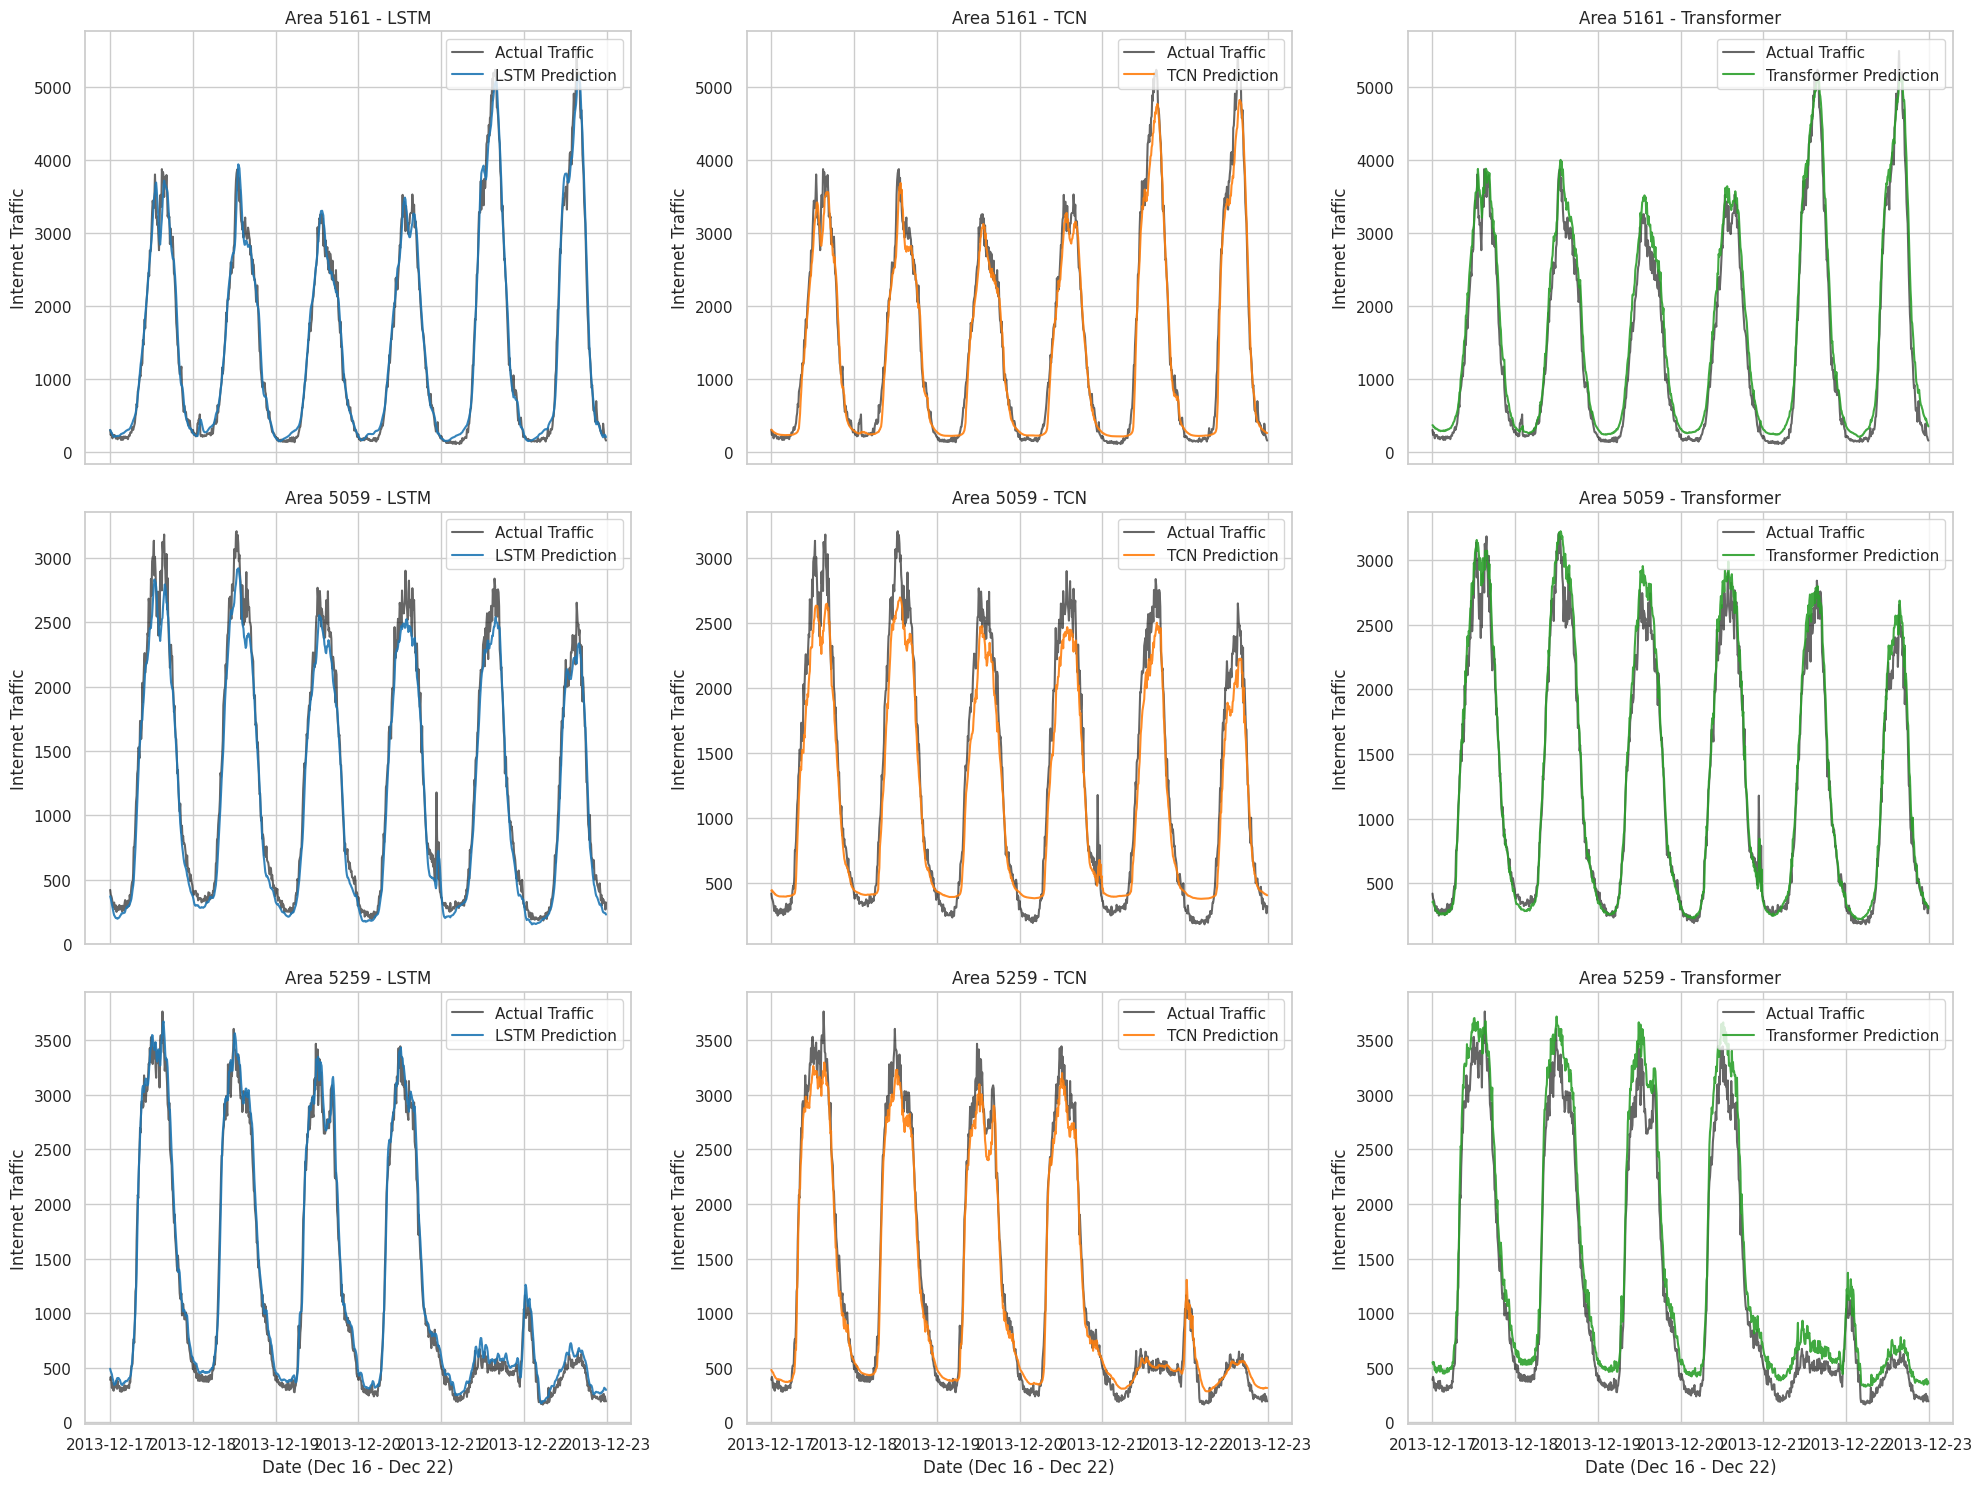


Performance Table for Area 5161
-----------------------------------------------------------------
      Model        MAE       RMSE  MAPE (%)  Train Time (s)  Infer Time (s)
       LSTM 108.500000 152.529999 16.260000            6.50          0.0445
        TCN 146.339996 211.729996 19.080000            5.99          0.0224
Transformer 196.830002 239.729996 32.259998           38.43          0.1161
-----------------------------------------------------------------

Performance Table for Area 5059
-----------------------------------------------------------------
      Model        MAE       RMSE  MAPE (%)  Train Time (s)  Infer Time (s)
       LSTM 110.790001 146.669998     12.05            5.38          0.0237
        TCN 171.729996 216.589996     21.08            5.61          0.0298
Transformer  94.040001 136.779999      8.73           38.12          0.1154
-----------------------------------------------------------------

Performance Table for Area 5259
-----------------------------

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

top_3_areas = [5161, 5059, 5259]
final_metrics = []

# Prepare a 3x3 grid for the 9 superposed plots
fig, axes = plt.subplots(3, 3, figsize=(20, 15), sharex=True)
model_names = ["LSTM", "TCN", "Transformer"]

eval_start = pd.to_datetime('2013-12-16')
eval_end = pd.to_datetime('2013-12-23')

for row_idx, area_id in enumerate(top_3_areas):
    print(f"\n{'='*50}\nProcessing Area {area_id}\n{'='*50}")

    # 1. Data Prep for this specific area
    area_df = master_df[master_df['Square_ID'] == area_id].copy()
    area_df.sort_values('Time_Interval', inplace=True)

    train_df = area_df[area_df['Time_Interval'] < eval_start]
    test_df = area_df[(area_df['Time_Interval'] >= eval_start) & (area_df['Time_Interval'] < eval_end)]

    train_data = train_df['Internet_Traffic'].values.reshape(-1, 1)
    test_data = test_df['Internet_Traffic'].values.reshape(-1, 1)
    test_times = test_df['Time_Interval'].values[SEQ_LENGTH:] # Align timestamps with predictions

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)

    train_dataset = TrafficDataset(train_scaled, SEQ_LENGTH)
    test_dataset = TrafficDataset(test_scaled, SEQ_LENGTH)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Re-instantiate fresh models for each area to prevent data leakage
    models = {
        "LSTM": LSTMForecaster(input_size=1, hidden_size=64, num_layers=2),
        "TCN": TCNForecaster(num_inputs=1, num_channels=[32, 64, 64], kernel_size=3),
        "Transformer": TransformerForecaster(feature_size=1, d_model=64, nhead=4, num_layers=2)
    }

    for col_idx, (name, model) in enumerate(models.items()):
        # Train and Evaluate
        res = train_and_evaluate(model, train_loader, test_loader, scaler, epochs=15, lr=0.001)

        # Log metrics for the tables
        final_metrics.append({
            "Area": area_id,
            "Model": name,
            "MAE": round(res['MAE'], 2),
            "RMSE": round(res['RMSE'], 2),
            "MAPE (%)": round(res['MAPE'], 2),
            "Train Time (s)": round(res['Train_Time_sec'], 2),
            "Infer Time (s)": round(res['Inference_Time_sec'], 4)
        })

        # Task 4.II: Superposed time series plot
        ax = axes[row_idx, col_idx]
        ax.plot(test_times, res['Targets'], label='Actual Traffic', color='black', alpha=0.6, linewidth=1.5)
        ax.plot(test_times, res['Predictions'], label=f'{name} Prediction', color=sns.color_palette("tab10")[col_idx], linewidth=1.5, alpha=0.9)

        ax.set_title(f"Area {area_id} - {name}")
        ax.set_ylabel("Internet Traffic")
        if row_idx == 2:
            ax.set_xlabel("Date (Dec 16 - Dec 22)")
        ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/milan_data/superposed_predictions.png', dpi=300)
plt.show()

# Generate the three tables required for Task 4.III
results_df = pd.DataFrame(final_metrics)
for area_id in top_3_areas:
    print(f"\nPerformance Table for Area {area_id}")
    print("-" * 65)
    area_table = results_df[results_df["Area"] == area_id].drop(columns=["Area"])
    print(area_table.to_string(index=False))
    print("-" * 65)